<a href="https://colab.research.google.com/github/ofer-geo/public_transport_ML/blob/Tamir_work/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('../data/interim_data/telaviv_buses_0501_1801_2024_cleaned_new_features.csv')
print(f"גודל: {df.shape}")
print(df.head())

גודל: (214634, 35)
         date     day  hour_rounded line_num  \
0  2024-01-05  Friday             0       61   
1  2024-01-05  Friday             0        2   
2  2024-01-05  Friday             0      699   
3  2024-01-05  Friday             0      555   
4  2024-01-05  Friday             0        8   

                                           line_name  route_id  route_mkt  \
0   הכובשים/דניאל-תל אביב יפו<->מסוף עמידר-רמת גן-10      2510    16061.0   
1  פרופ' ישעיהו ליבוביץ'/הרב יעקב טראב-תל אביב יפ...     27082    99002.0   
2  הרכבת/ראש פינה-תל אביב יפו<->ת. מרכזית נתניה-נ...     22058    11699.0   
3  מסוף רדינג/רציפים-תל אביב יפו<->מסוף יהוד/הורד...      1048    11555.0   
4  מסוף אונברסיטת ת''א-תל אביב יפו<->מסוף הטייסים...     16076    55008.0   

   direction alternative agency_name  ... rainfall_mm length_in_buffer_m  \
0        1.0           0         Dan  ...         0.0        1528.828626   
1        2.0           0         Dan  ...         0.0        5074.525101   
2

In [2]:
df.head()

,date,day,hour_rounded,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,rainfall_mm,length_in_buffer_m,route_length,perc_within_pt_route,curvity,line_num_agency_alter_dir,urban,route_dir_alt_day_hr,Total_Passengers,Avg_Passengers_Per_Bus
0,2024-01-05,Friday,0,61,הכובשים/דניאל-תל אביב יפו<->מסוף עמידר-רמת גן-10,2510,16061.0,1.0,0,Dan,...,0.0,1528.828626,12797.049700,11.95,1.843115,Dan_61_1.0,False,16061_1_0_Friday_0,87.0,29.0
1,2024-01-05,Friday,0,2,פרופ' ישעיהו ליבוביץ'/הרב יעקב טראב-תל אביב יפ...,27082,99002.0,2.0,0,Dan,...,0.0,5074.525101,19588.509346,25.91,2.517371,Dan_2_2.0,False,99002_2_0_Friday_0,11.0,5.5
2,2024-01-05,Friday,0,699,הרכבת/ראש פינה-תל אביב יפו<->ת. מרכזית נתניה-נ...,22058,11699.0,2.0,#,Metropolin,...,0.0,21555.169188,35080.611916,61.44,1.149308,Metropolin_699_2.0,False,11699_2_#_Friday_0,1.0,1.0
3,2024-01-05,Friday,0,555,מסוף רדינג/רציפים-תל אביב יפו<->מסוף יהוד/הורד...,1048,11555.0,1.0,0,Kavim,...,0.0,7372.369073,20643.347935,35.71,1.561211,Kavim_555_1.0,False,11555_1_0_Friday_0,NaN,NaN
4,2024-01-05,Friday,0,8,מסוף אונברסיטת ת''א-תל אביב יפו<->מסוף הטייסים...,16076,55008.0,1.0,0,Dan,...,0.0,5123.405002,14665.598732,34.93,1.916634,Dan_8_1.0,False,55008_1_0_Friday_0,17.0,8.5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214634 entries, 0 to 214633
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date                       214634 non-null  datetime64[ns]
 1   day                        214634 non-null  category      
 2   hour_rounded               214634 non-null  int64         
 3   line_num                   214627 non-null  object        
 4   line_name                  214634 non-null  object        
 5   route_id                   214634 non-null  int64         
 6   route_mkt                  212510 non-null  float64       
 7   direction                  214627 non-null  float64       
 8   alternative                214627 non-null  object        
 9   agency_name                214005 non-null  object        
 10  route_type                 214634 non-null  object        
 11  origin_city                214627 non-null  object  

In [29]:
missing_summary = df.isnull().sum().reset_index()
missing_summary.columns = ['column', 'missing_count']
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary['missing_count'] > 0]
print(missing_summary)

                       column  missing_count  missing_pct
3                    line_num            490         0.23
6                   route_mkt           2124         0.99
7                   direction              7         0.00
8                 alternative              7         0.00
9                 agency_name            629         0.29
11                origin_city              7         0.00
13           destination_city              7         0.00
20        duration_min_actual            261         0.12
21    duration_difference_min            261         0.12
23           speed_kmh_actual            261         0.12
26         length_in_buffer_m           2898         1.35
27               route_length           2891         1.35
28       perc_within_pt_route           2898         1.35
29                    curvity           2898         1.35
30  line_num_agency_alter_dir            636         0.30
33           Total_Passengers          38772        18.06
34     Avg_Pas

## Features Organization

### Date to Date Type

In [4]:
df['date'] = pd.to_datetime(df['date'])

print(df['date'].dtype)

datetime64[ns]


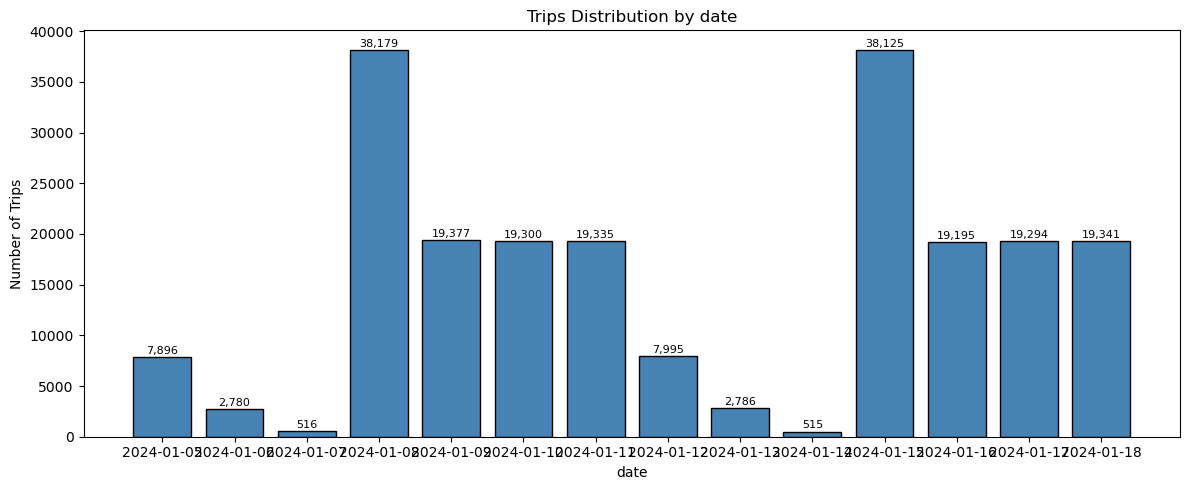

In [17]:
plt.figure(figsize=(12, 5))
counts = df['date'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )

plt.title('Trips Distribution by date')
plt.xlabel('date')
plt.ylabel('Number of Trips')
plt.xticks(counts.index, rotation=0)
plt.tight_layout()
plt.show()

### Day to Categorical

In [6]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)

print(df['day'].dtype)
print(df['day'].unique())

category
['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Categories (7, object): ['Sunday' < 'Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday']


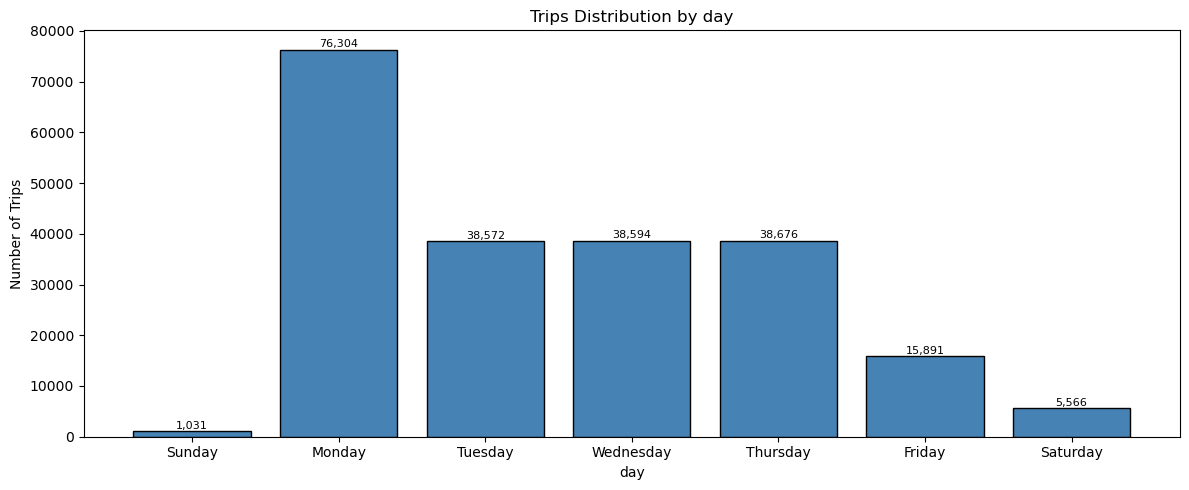

In [16]:
plt.figure(figsize=(12, 5))
counts = df['day'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )

plt.title('Trips Distribution by day')
plt.xlabel('day')
plt.ylabel('Number of Trips')
plt.xticks(counts.index, rotation=0)
plt.tight_layout()
plt.show()

### Hour

In [10]:
df = df.rename(columns={'hour_rounded': 'full_hour'})

print(df['full_hour'].head())

0    0
1    0
2    0
3    0
4    0
Name: full_hour, dtype: int64


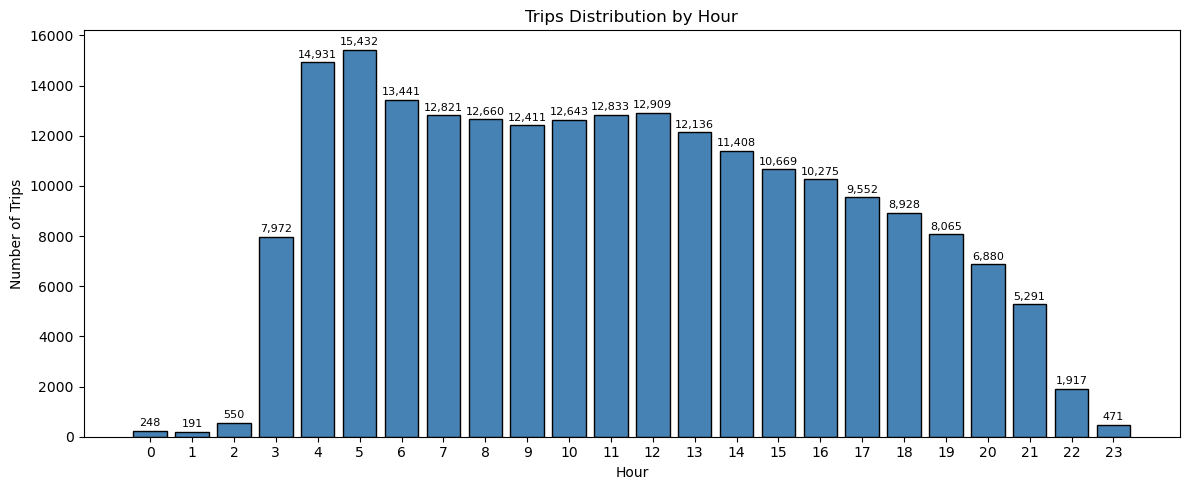

In [15]:
plt.figure(figsize=(12, 5))
counts = df['full_hour'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )

plt.title('Trips Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.xticks(counts.index, rotation=0)
plt.tight_layout()
plt.show()

### Line_Num

In [20]:
df['line_num'] = pd.to_numeric(df['line_num'], errors='coerce').astype('Int64')

print(df['line_num'].dtype)
print(df['line_num'].isna().sum(), "missing values")

Int64
490 missing values


In [21]:
print(df[df['line_num'].isna()][['date', 'day', 'full_hour', 'line_num']].head(10))

           date     day  full_hour  line_num
561  2024-01-05  Friday          4      <NA>
1267 2024-01-05  Friday          5      <NA>
1372 2024-01-05  Friday          5      <NA>
2222 2024-01-05  Friday          6      <NA>
2227 2024-01-05  Friday          6      <NA>
2346 2024-01-05  Friday          6      <NA>
2686 2024-01-05  Friday          6      <NA>
2948 2024-01-05  Friday          7      <NA>
3067 2024-01-05  Friday          7      <NA>
3518 2024-01-05  Friday          7      <NA>


In [22]:
missing_by_date = df[df['line_num'].isna()].groupby('date').size().reset_index(name='missing_count')
print(missing_by_date)

         date  missing_count
0  2024-01-05             24
1  2024-01-07              1
2  2024-01-08             85
3  2024-01-09             47
4  2024-01-10             47
5  2024-01-11             43
6  2024-01-12             25
7  2024-01-15             88
8  2024-01-16             43
9  2024-01-17             44
10 2024-01-18             43


In [26]:
missing_by_hour = df[df['line_num'].isna()].groupby('full_hour').size().reset_index(name='missing_count')
print(missing_by_hour)

    full_hour  missing_count
0           4             33
1           5             24
2           6             37
3           7             37
4           8             36
5           9             36
6          10             35
7          11             34
8          12             31
9          13             30
10         14             30
11         15             28
12         16             21
13         17             19
14         18             19
15         19             20
16         20             20


In [28]:
missing_by_line_num = df[df['line_num'].isna()].groupby('line_num').size().reset_index(name='missing_count')
print(missing_by_line_num)                

Empty DataFrame
Columns: [line_num, missing_count]
Index: []


### Line_Name

In [31]:
df['line_name'] = df['line_name'].astype(str)

print(df['line_name'].dtype)
print(df['line_name'].head())

object
0     הכובשים/דניאל-תל אביב יפו<->מסוף עמידר-רמת גן-10
1    פרופ' ישעיהו ליבוביץ'/הרב יעקב טראב-תל אביב יפ...
2    הרכבת/ראש פינה-תל אביב יפו<->ת. מרכזית נתניה-נ...
3    מסוף רדינג/רציפים-תל אביב יפו<->מסוף יהוד/הורד...
4    מסוף אונברסיטת ת''א-תל אביב יפו<->מסוף הטייסים...
Name: line_name, dtype: object


### Route_mkt

In [32]:
identical = (df['route_id'] == df['route_mkt']).all()
print(f"Are route_id and route_mkt identical? {identical}")

diff_count = (df['route_id'] != df['route_mkt']).sum()
print(f"Number of different values: {diff_count}")

if diff_count > 0:
    print(df[df['route_id'] != df['route_mkt']][['route_id', 'route_mkt']].head(10))

Are route_id and route_mkt identical? False
Number of different values: 214634
   route_id  route_mkt
0      2510    16061.0
1     27082    99002.0
2     22058    11699.0
3      1048    11555.0
4     16076    55008.0
5      2949    11418.0
6      2948    11418.0
7      2950    10463.0
8      2953    10466.0
9     17214    12174.0


In [34]:
print(df['route_mkt'].isna().sum(), "missing values")

2124 missing values
